# RetOCTNet — pretrained inference on rat OCT B-scans (Retinal Ganglion Cell injury)

**Paper:** Afeola et al., *"RetOCTNet: Deep Learning–Based Segmentation of OCT Images Following Retinal Ganglion Cell Injury"*, Translational Vision Science & Technology 14(2):4, 2025. DOI: [10.1167/tvst.14.2.4](https://doi.org/10.1167/tvst.14.2.4) ([PMC11801391](https://pmc.ncbi.nlm.nih.gov/articles/PMC11801391/))

**Author code:** [github.com/afeola2/RetOCTNet](https://github.com/afeola2/RetOCTNet) @ commit `f16f0d7b107742ea36892f257ca28b61b04f4245` (MIT license file in repository).

**Scope of this notebook (partial demonstration):** load the authors' committed whole-model `weights.h5` and run their own inference path (`usage_utils.drn_execute`, used verbatim) on the four author-provided averaged radial rat OCT B-scans in `TestOCT/`, then summarize predicted RNFL and total-retina thickness per A-scan.

**Not in scope:** training, dataset-level F1/IoU metrics (the annotated dataset is not public), the volumetric ONC cohort analysis, the mouse cross-species test, and cohort-level uncertainty maps.

**Execution status:** validated top-to-bottom on a fresh Google Colab **CPU** runtime (2026-10-08). GPU is optional (TensorFlow would use it automatically) but was not part of the validation.

**日本語:** このノートブックは RetOCTNet 論文（TVST 14(2):4, 2025）の学習済みモデル `weights.h5` を、著者自身の推論コード（`usage_utils.drn_execute`、改変なし）で著者提供のラット radial OCT B-scan 4 枚に適用し、A-scan ごとの RNFL／網膜厚を要約します。学習やデータセット全体の精度再現は対象外です（アノテーション済みデータは非公開）。Colab CPU ランタイムで検証済み（2026-10-08）。

## 1. Runtime selection

**Select Runtime → Change runtime type → CPU (recommended).** The demonstration is a single forward pass on 512×512 patches of a ~81 MB model; CPU is sufficient (~minutes). A GPU (T4) also works — TensorFlow uses it automatically — but the CPU path is what was validated here. Expected total: ~10–15 min including a ~90 MB download (`weights.h5` ≈ 81 MB + four ~2 MB TIFFs).

**日本語:** 「ランタイム → ランタイムのタイプを変更」で **CPU（推奨）** を選択してください。単一 B-scan 群の推論は CPU で十分です。T4 GPU でも動作しますが、検証は CPU で実施済みです。所要時間の目安はダウンロード約 90 MB 込みで 10–15 分です。

### 1.1 Environment setup

The weights were saved as a whole-model Keras H5 with TensorFlow 2.10 (per the authors' `environment.yml`). Colab ships a newer TF, so we set `TF_USE_LEGACY_KERAS=1` **before importing TensorFlow** and install `tf-keras` (the Keras team's official legacy-Keras-2 package). This routes `tf.keras` to the Keras 2 API, which is the documented compatibility route for legacy H5 models. Expected result: TF and tf-keras versions printed, and the list of GPUs visible to TF (empty on CPU).

**日本語:** `weights.h5` は TF 2.10 保存の Keras H5 です。Colab の新しめの TF で読み込むため、TF import 前に `TF_USE_LEGACY_KERAS=1` を設定し、公式の互換パッケージ `tf-keras` をインストールします。

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # must be set before TensorFlow is imported

import subprocess, sys
probe = subprocess.run([sys.executable, "-c", "import tf_keras"], capture_output=True)
if probe.returncode != 0:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tf-keras"], check=True)

import tensorflow as tf
import tf_keras
print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__, "| tf-keras:", tf_keras.__version__)
print("GPUs visible to TF:", tf.config.list_physical_devices("GPU"))

Python: 3.13.16
TensorFlow: 2.21.0 | tf-keras: 2.21.0
GPUs visible to TF: []


## 2. Minimal inputs from the pinned author repository

Everything needed is public in the author repository at commit `f16f0d7b`: `weights.h5` (80,964,688 bytes), four averaged radial B-scans `TestOCT/2022-08-15_OS_R_3_0_0000006_averaged_{1..4}.tiff`, and the inference modules `usage_utils.py`, `datagen.py`, `post_processing.py`. Each file is verified in-memory against its **git blob SHA-1 and exact byte size** recorded from the pinned repository tree; a mismatch aborts. All model/dataset bytes stay inside this Colab VM (`/content/ret-octnet`).

**日本語:** 必要なファイルはすべてピン留めしたコミット `f16f0d7b` の著者リポジトリから取得します。各ファイルは git blob SHA-1 とバイト数で検証し、不一致なら中断します。ダウンロードはすべて Colab VM 内に置かれます。

In [ ]:
import hashlib, urllib.request

COMMIT = "f16f0d7b107742ea36892f257ca28b61b04f4245"
BASE = f"https://raw.githubusercontent.com/afeola2/RetOCTNet/{COMMIT}/"
EXPECTED = {  # relative path -> (exact byte size, git blob SHA-1) from the pinned repository tree
    "weights.h5": (80964688, "f2e33b00da3be60f3d2114f525f2d474ecd9d336"),
    "TestOCT/2022-08-15_OS_R_3_0_0000006_averaged_1.tiff": (2065156, "c3814de812eddb597e2f76326b0230504c6c2f1d"),
    "TestOCT/2022-08-15_OS_R_3_0_0000006_averaged_2.tiff": (2065260, "37d0928621aecc313bcc96feb9ddef6ce14f1e8e"),
    "TestOCT/2022-08-15_OS_R_3_0_0000006_averaged_3.tiff": (2065266, "0efd6163882a74a0d0343f69cf96933bd45b0087"),
    "TestOCT/2022-08-15_OS_R_3_0_0000006_averaged_4.tiff": (2065226, "57ae588c2a4e3e183510d0c90aac3f2bb484601a"),
    "usage_utils.py": (10387, "db2de3c30c5b6160001a241c48e7dbcb739723d8"),
    "datagen.py": (812, "3d5ff85c495d9890afc1dd482482e16ca04b494f"),
    "post_processing.py": (1839, "1fad2cba7478651fe811f32080ac287f6f00d3d0"),
}
ROOT = "/content/ret-octnet"
for rel, (size, blob) in EXPECTED.items():
    dest = os.path.join(ROOT, rel)
    if not os.path.exists(dest) or os.path.getsize(dest) != size:
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        urllib.request.urlretrieve(BASE + rel, dest)
    data = open(dest, "rb").read()
    digest = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    ok = digest == blob and len(data) == size
    print(f"{rel}: {len(data)} bytes " + ("OK" if ok else "MISMATCH"))
    assert ok, f"verification failed for {rel}" 

weights.h5: 80964688 bytes OK
TestOCT/2022-08-15_OS_R_3_0_0000006_averaged_1.tiff: 2065156 bytes OK


TestOCT/2022-08-15_OS_R_3_0_0000006_averaged_2.tiff: 2065260 bytes OK


TestOCT/2022-08-15_OS_R_3_0_0000006_averaged_3.tiff: 2065266 bytes OK


TestOCT/2022-08-15_OS_R_3_0_0000006_averaged_4.tiff: 2065226 bytes OK
usage_utils.py: 10387 bytes OK


datagen.py: 812 bytes OK
post_processing.py: 1839 bytes OK


## 3. Input preview

Before any inference, display the four author-provided B-scans. These are 8-bit grayscale radial OCT scans; their actual pixel geometry is printed in the titles (the authors' `drn_execute` pads whatever geometry it finds to multiples of 512, so no manual resizing is needed).

**日本語:** 推論前に著者提供の 4 枚の B-scan を表示します。各タイトルに実際の画素サイズを表示します（パディングは著者コードが自動処理します）。

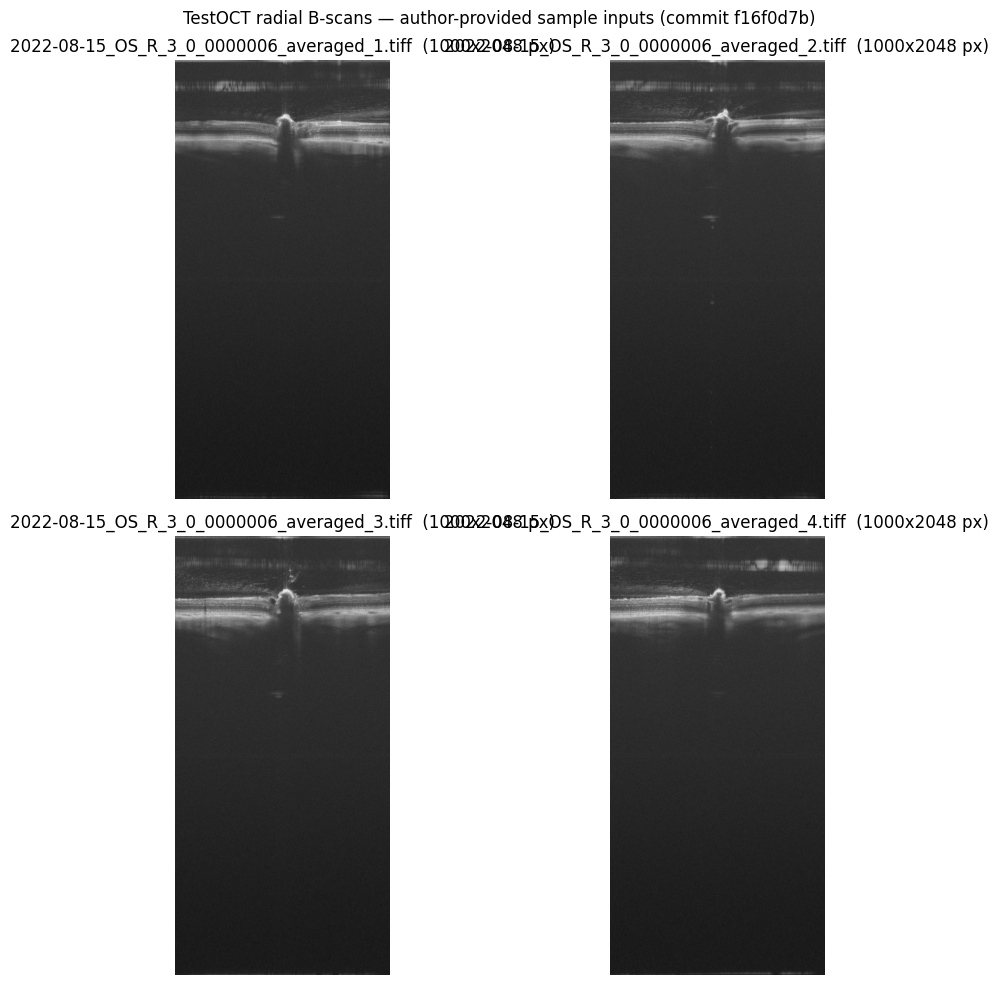

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

tiff_files = sorted(glob.glob("/content/ret-octnet/TestOCT/*.tiff"))
assert len(tiff_files) == 4, tiff_files
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, path in zip(axes.ravel(), tiff_files):
    a = np.array(Image.open(path))
    ax.imshow(a, cmap="gray")
    ax.set_title(os.path.basename(path) + f"  ({a.shape[1]}x{a.shape[0]} px)")
    ax.axis("off")
plt.suptitle("TestOCT radial B-scans — author-provided sample inputs (commit f16f0d7b)")
plt.tight_layout()
plt.show()

## 4. Run the authors' inference code verbatim

`usage_utils.drn_execute` (used unchanged, as in the authors' `execute.py --image_dir ...`) does: grayscale load → symmetric pad to multiples of 512 (top/left only) → non-overlapping 512×512 patches → per-patch `StandardScaler` normalization → `model.predict` → 3-class argmax → restitch and unpad. The model was trained on 3 classes: 0 = background, 1 = RNFL, 2 = remaining retina (ILM-to-choroid). We change the working directory to the code folder because `drn_execute` loads `./weights.h5` relatively.

**日本語:** 著者の `drn_execute` をそのまま実行します（グレースケール読み込み → 512 の倍数に対称パディング → 512×512 パッチ → StandardScaler 正規化 → predict → 3 クラス argmax → 再構築）。クラスは 0=背景、1=RNFL、2=その他の網膜です。

In [ ]:
import sys

os.chdir("/content/ret-octnet")  # drn_execute loads './weights.h5' relative to cwd
sys.path.insert(0, "/content/ret-octnet")
import usage_utils  # verbatim author module (commit f16f0d7b)

tiff_files = sorted(glob.glob("TestOCT/*.tiff"))
print("Sample scans:", [os.path.basename(t) for t in tiff_files])

Sample scans: ['2022-08-15_OS_R_3_0_0000006_averaged_1.tiff', '2022-08-15_OS_R_3_0_0000006_averaged_2.tiff', '2022-08-15_OS_R_3_0_0000006_averaged_3.tiff', '2022-08-15_OS_R_3_0_0000006_averaged_4.tiff']


### 4.1 Inference on the four B-scans

Expected: `drn_execute` prints the stitched prediction shape — (2048, 1000, 1, 4) for these 2048×1000 scans — and per-pixel classes limited to {0, 1, 2}. This is the authors' complete, unchanged inference path; the wall time is measured but not assumed.

**日本語:** 4 枚の B-scan に対して著者の推論パスを実行します。予測は元の 2048×1000 形状に再構築され、クラスは {0,1,2} のみです。

In [ ]:
import time

t0 = time.time()
images, predictions = usage_utils.drn_execute(tiff_files)  # author inference path, unchanged
print(f"drn_execute finished in {time.time() - t0:.1f} s")
print("images:", images.shape, "| predictions:", predictions.shape)
print("predicted classes:", np.unique(predictions))

 1/32 [..............................] - ETA: 4:44

 2/32 [>.............................] - ETA: 3:47

 3/32 [=>............................] - ETA: 3:46

 4/32 [==>...........................] - ETA: 3:40

 5/32 [===>..........................] - ETA: 3:30

...

30/32 [===========================>..] - ETA: 15s

31/32 [============================>.] - ETA: 7s 

32/32 [==============================] - ETA: 0s

32/32 [==============================] - 255s 8s/step


drn_execute finished in 258.1 s
images: (2048, 1000, 1, 4) | predictions: (2048, 1000, 1, 4)
predicted classes: [0. 1. 2.]


### 4.2 Optional author post-processing (default: off)

The authors' CLI (`execute.sh`) defaults to `POST_PROCESSING=False`; when enabled it keeps only the largest connected component of RNFL+retina pixels per image (via OpenCV). We keep the author default here so the thickness values below come from the raw argmax masks.

**日本語:** 著者の CLI 既定では 後処理はオフ（`POST_PROCESSING=False`）です。ここでは既定に従い生の argmax マスクを使用します（オンにすると RNFL＋網膜の最大連結成分のみを残します）。

In [ ]:
APPLY_POST_PROCESSING = False  # author default in execute.sh

if APPLY_POST_PROCESSING:
    import post_processing  # verbatim author module
    predictions = post_processing.process_images(predictions)
    print("Applied author post-processing (largest RNFL+retina connected component).")
else:
    print("Skipped author post-processing (author CLI default POST_PROCESSING=False).")

Skipped author post-processing (author CLI default POST_PROCESSING=False).


## 5. Prediction visualization

The colormap follows the authors' `save_images_with_color`: **black = background, grey = RNFL, white = remaining retina**. The left panel is the original B-scan, the middle is the model prediction, and the right is an input+prediction overlay. **These are model predictions of this notebook — there are no public reference annotations for these four scans, so they are not compared against ground truth here.**

**日本語:** カラーマップは著者の `save_images_with_color` に従います（黒=背景、灰=RNFL、白=その他の網膜）。これらはモデル予測であり、公開されている参照アノテーションは無いため比較は行いません。

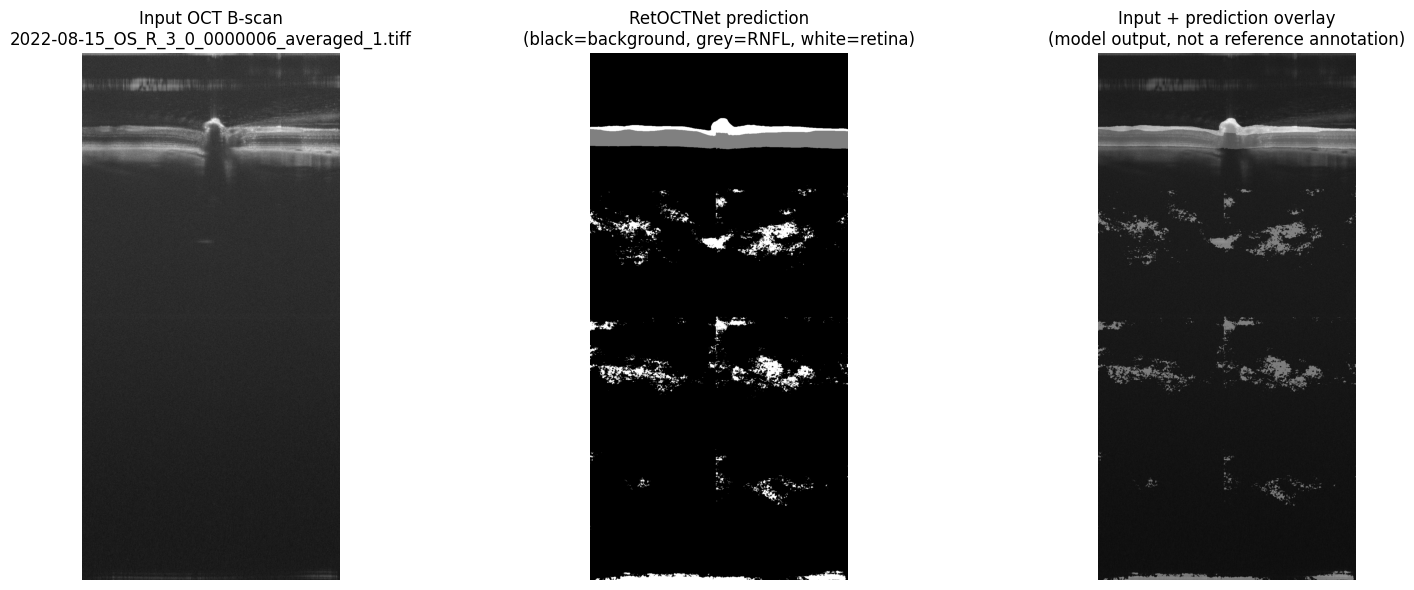

In [ ]:
COLORMAP = {0: (0, 0, 0), 1: (128, 128, 128), 2: (255, 255, 255)}  # author colormap

def prediction_to_rgb(pred2d):
    rgb = np.zeros(pred2d.shape + (3,), dtype=np.uint8)
    for value, color in COLORMAP.items():
        rgb[pred2d == value] = color
    return rgb

i0 = 0
im0 = images[:, :, 0, i0]
pred0 = predictions[:, :, 0, i0]
gray = plt.get_cmap("gray")(im0 / 255.0)[..., :3]
blend = 0.6 * gray + 0.4 * (prediction_to_rgb(pred0) / 255.0)

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
axes[0].imshow(im0, cmap="gray")
axes[0].set_title(f"Input OCT B-scan\n{os.path.basename(tiff_files[i0])}")
axes[1].imshow(prediction_to_rgb(pred0))
axes[1].set_title("RetOCTNet prediction\n(black=background, grey=RNFL, white=retina)")
axes[2].imshow(blend)
axes[2].set_title("Input + prediction overlay\n(model output, not a reference annotation)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 5.1 All four scans with prediction overlays

**日本語:** 残り 3 枚を含む 4 枚すべてのオーバーレイ表示です。

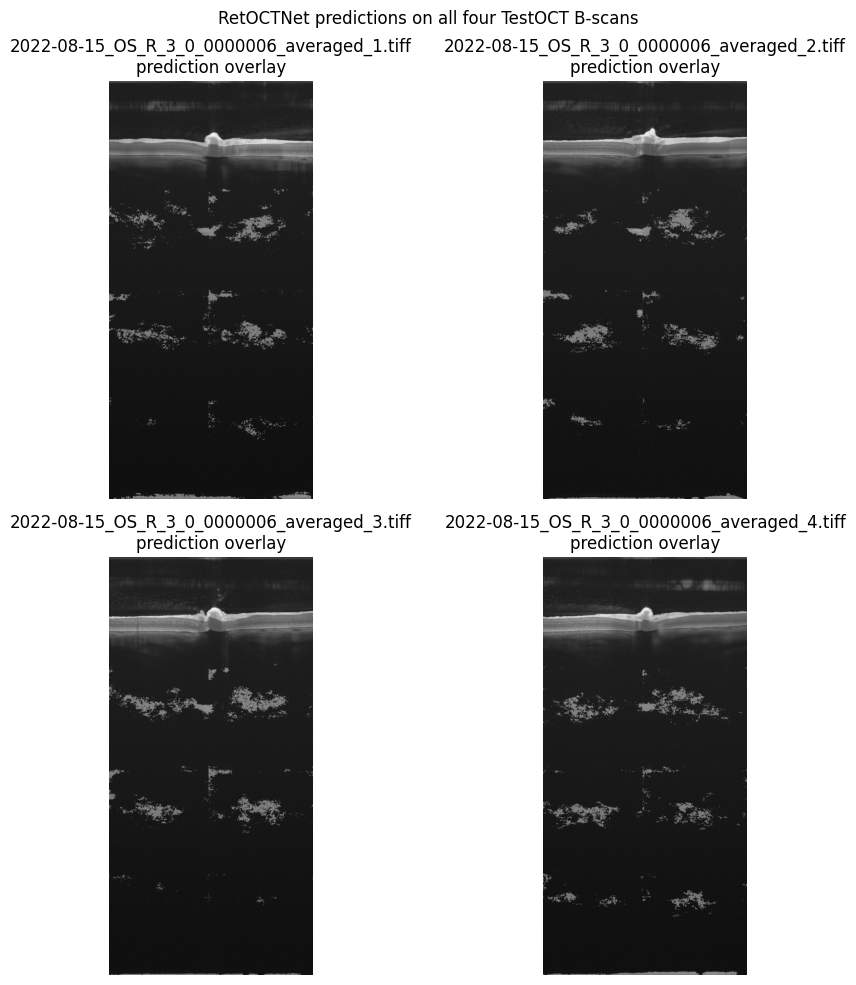

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, i in zip(axes.ravel(), range(images.shape[3])):
    im = images[:, :, 0, i]
    gray = plt.get_cmap("gray")(im / 255.0)[..., :3]
    ax.imshow(0.6 * gray + 0.4 * (prediction_to_rgb(predictions[:, :, 0, i]) / 255.0))
    ax.set_title(os.path.basename(tiff_files[i]) + "\nprediction overlay")
    ax.axis("off")
plt.suptitle("RetOCTNet predictions on all four TestOCT B-scans")
plt.tight_layout()
plt.show()

## 6. Thickness per A-scan

As in the paper's evaluation, thickness is counted per A-scan column: **RNFL thickness** = number of class-1 pixels in the column; **total retinal thickness** = number of class-1 + class-2 pixels. The paper's radial scans span 3.0 mm with 1000 A-scans, so the lateral axis is labeled in µm (3 µm per A-scan). **Axial µm/pixel calibration is not published in the repository or the paper's accessible text, so thickness is reported in pixels — no calibration is invented here.** This profile plot is an additional visualization created for this notebook, not an author figure.

**日本語:** A-scan ごとにクラス 1（RNFL）、クラス 1+2（網膜全体）のピクセル数を厚みとして計上します。横方向は 3.0 mm／1000 A-scan より 3 µm/A-scan です。軸方向の µm/px 较正は公表されていないため、厚みはピクセル単位で報告します（勝手な较正は行いません）。このプロファイル図は本ノートブックで追加作成した可視化であり、論文の図ではありません。

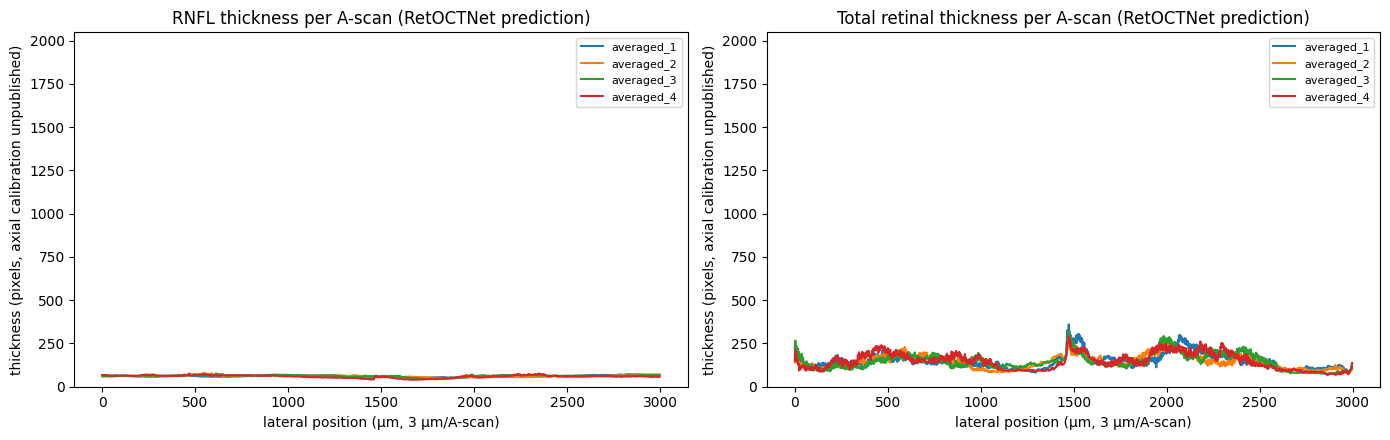

In [ ]:
col_rnfl = (predictions == 1).sum(axis=0)[:, 0, :]                       # (1000 A-scans, 4 scans), pixels
col_retina = ((predictions == 1) | (predictions == 2)).sum(axis=0)[:, 0, :]
LATERAL_UM_PER_ASCAN = 3.0  # 3.0-mm radial scan / 1000 A-scans (paper Methods)
x_um = np.arange(col_rnfl.shape[0]) * LATERAL_UM_PER_ASCAN

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for i in range(4):
    label = os.path.basename(tiff_files[i]).replace("2022-08-15_OS_R_3_0_0000006_", "").replace(".tiff", "")
    axes[0].plot(x_um, col_rnfl[:, i], label=label)
    axes[1].plot(x_um, col_retina[:, i], label=label)
axes[0].set_title("RNFL thickness per A-scan (RetOCTNet prediction)")
axes[1].set_title("Total retinal thickness per A-scan (RetOCTNet prediction)")
for ax in axes:
    ax.set_xlabel("lateral position (µm, 3 µm/A-scan)")
    ax.set_ylabel("thickness (pixels, axial calibration unpublished)")
    ax.set_ylim(0, 2048)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 6.1 Thickness summary table and CSV export

A small summary of the per-A-scan thickness profiles (mean/max over the 1000 A-scans of each scan), plus a CSV export for further use inside Colab.

**日本語:** 各スキャンの A-scan 方向の厚みプロファイルの平均・最大値を表にまとめ、CSV に保存します。

In [ ]:
import pandas as pd

rows = []
for i in range(4):
    rows.append({
        "scan": os.path.basename(tiff_files[i]),
        "RNFL_mean_px": float(col_rnfl[:, i].mean()),
        "RNFL_max_px": int(col_rnfl[:, i].max()),
        "retina_mean_px": float(col_retina[:, i].mean()),
        "retina_max_px": int(col_retina[:, i].max()),
    })
summary = pd.DataFrame(rows)
display(summary)
summary.to_csv("/content/ret-octnet/thickness_summary.csv", index=False)
print("saved: /content/ret-octnet/thickness_summary.csv")

,scan,RNFL_mean_px,RNFL_max_px,retina_mean_px,retina_max_px
0,2022-08-15_OS_R_3_0_0000006_averaged_1.tiff,60.659,72,149.237,360
1,2022-08-15_OS_R_3_0_0000006_averaged_2.tiff,61.410,82,143.865,264
2,2022-08-15_OS_R_3_0_0000006_averaged_3.tiff,62.420,76,146.353,323
3,2022-08-15_OS_R_3_0_0000006_averaged_4.tiff,59.271,77,148.124,295


saved: /content/ret-octnet/thickness_summary.csv


## 7. Interpretation and limitations

**What was executed:** the authors' committed `weights.h5` and their unchanged inference path were applied to the four author-provided rat radial B-scans; predictions segmented a thin RNFL band and a thicker total-retina band along each A-scan, as expected for radial OCT through the optic nerve head region.

**What this does NOT establish:** the paper's reported test-set performance (F1 ≈ 0.88 RNFL / 0.98 retina, thickness bias < 1.7 µm) is a dataset-level result over 192 expert-annotated scans; the annotated dataset is not public (authors share "upon reasonable request"), so no quantitative accuracy check is possible here. The four sample scans have no public reference annotations either. Thickness is in pixels because no axial µm/px calibration is published. GPU behavior was not validated (CPU validation only).

**日本語:** 本ノートブックは著者の学習済みモデルと推論コードをそのまま用い、著者提供の 4 枚のサンプルに対して RNFL／網膜のセグメンテーションと厚み集計を実行しました。論文のデータセット全体の精度（F1 0.88/0.98 など）の再現は、アノテーション済みデータが非公開のため対象外です。サンプルにも参照アノテーションは無く、定量的な精度検証は行っていません。軸方向较正が未公表のため厚みはピクセル単位です。GPU は未検証（CPU で検証済み）。

## 8. References

1. Afeola et al., "RetOCTNet: Deep Learning–Based Segmentation of OCT Images Following Retinal Ganglion Cell Injury," *Transl. Vis. Sci. Technol.* 14(2):4, 2025. DOI: 10.1167/tvst.14.2.4 — PMC: https://pmc.ncbi.nlm.nih.gov/articles/PMC11801391/
2. Author code and sample data: https://github.com/afeola2/RetOCTNet @ `f16f0d7b107742ea36892f257ca28b61b04f4245` (MIT license).
3. FC-DenseNet architecture: Jégou et al., "The One Hundred Layers Tiramisu," CVPR 2017 (per the paper's Methods).
4. PhenoPaper investigation record (AI-generated research guidance, not primary proof): run `p-7516120ffdbb96b635da0d88bf46d6b8-20261008T012147Z-580553`. All scientific operations in this notebook were verified directly against the pinned author code and repository tree.